# Levine et al. (2015) -- Mass Cytometry of Human Bone Marrow (32-dim)

**Source:** Levine et al., "Data-Driven Phenotypic Dissection of AML Reveals Progenitor-like Cells that Correlate with Prognosis." *Cell* 162.1 (2015): 184--197.

265,627 human bone marrow cells profiled by mass cytometry (CyTOF) across 32 protein markers, with 14 manually gated cell populations (39% of cells labeled = 104,184 cells). CyTOF data features heavy-tailed protein expression distributions and overlapping cell populations with varying densities -- properties known to challenge classical distance-based validation indices (Silhouette, Davies--Bouldin, Calinski--Harabasz).

Available via the HDCytoData Bioconductor package (Weber & Robinson, 2016).

---

## 0. Imports & Configuration

In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(repo_root / "src"))
sys.path.insert(0, str(repo_root / "notebooks" / "benchmarking_code"))

In [2]:
import multiprocessing
import os, random

from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import StratifiedShuffleSplit

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from carve import CARVE

from case_study_plotting import (
    baseline_metrics_over_k,
    build_baseline_best_labels,
    extract_ari_comparison,
    plot_ari_comparison_lollipop,
    plot_ari_comparison_bar,
    plot_ari_comparison_dotplot,
    plot_composite_figure,
    plot_dim_red,
    alluvial_compare,
)

In [3]:
# --- Configuration ---
SUBSAMPLE = True
subsample_size = 5000
RANDOM_SEED = 42
K = 30

# CARVE selection criteria
MEASURE = "s"   # stability
RULE = "1se"
NOT_TWO = True

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
os.environ["PYTHONHASHSEED"] = str(RANDOM_SEED)

def get_n_jobs():
    env_val = os.environ.get("CARVE_N_JOBS", None)
    if env_val is not None:
        try:
            return int(env_val)
        except ValueError:
            pass
    try:
        n_cores = multiprocessing.cpu_count()
    except NotImplementedError:
        n_cores = 4
    return max(1, n_cores - 1)

N_JOBS = get_n_jobs()
print(f"Using N_JOBS={N_JOBS} for parallel processing.")

Using N_JOBS=10 for parallel processing.


In [4]:
%env PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning

env: PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning


---

## 1. Load & Preprocess Data

Load from the HDCytoData R package via rpy2. Filter to labeled cells and type markers, apply arcsinh transform (CyTOF standard, cofactor=5) and robust scaling.

In [5]:
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri

ro.r(r"""
if (!requireNamespace("BiocManager", quietly=TRUE)) install.packages("BiocManager")
if (!requireNamespace("HDCytoData", quietly=TRUE)) BiocManager::install("HDCytoData")
library(HDCytoData)
library(SummarizedExperiment)
""")

ro.r("sce <- Levine_32dim_SE()")

X_all = np.array(ro.r("assay(sce)"), dtype=float)
row_df = pandas2ri.rpy2py(ro.r("as.data.frame(rowData(sce))"))
col_df = pandas2ri.rpy2py(ro.r("as.data.frame(colData(sce))"))

print(f"Full dataset: {X_all.shape[0]:,} cells x {X_all.shape[1]} markers")
print(f"Populations: {row_df['population_id'].nunique()} unique")
print(f"Labeled cells: {(row_df['population_id'] != 'unassigned').sum():,} / {X_all.shape[0]:,}")

R callback write-console: Loading required package: ExperimentHub
  
R callback write-console: Loading required package: BiocGenerics
  
R callback write-console: Loading required package: generics
  
R callback write-console: 
Attaching package: ‘generics’

  
R callback write-console: The following objects are masked from ‘package:base’:

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union

  
R callback write-console: 
Attaching package: ‘BiocGenerics’

  
R callback write-console: The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs

  
R callback write-console: The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames,

Full dataset: 265,627 cells x 39 markers
Populations: 15 unique
Labeled cells: 265,627 / 265,627


In [6]:
# Filter to labeled cells only
labeled_mask = (row_df["population_id"] != "unassigned").to_numpy()
X_labeled = X_all[labeled_mask]
y_labeled = row_df["population_id"].to_numpy()[labeled_mask]

# Filter to type markers (marker_class == 2)
keep_markers = (col_df["marker_class"].astype(int) == 2).to_numpy()
X_labeled = X_labeled[:, keep_markers]
marker_names = col_df.index[keep_markers].tolist()

print(f"Labeled cells: {X_labeled.shape[0]:,} x {X_labeled.shape[1]} markers")
print(f"Populations: {len(np.unique(y_labeled))}")
print()
print("Population distribution:")
print(pd.Series(y_labeled).value_counts().to_string())

Labeled cells: 265,627 x 32 markers
Populations: 15

Population distribution:
15    161443
7      26366
10     21099
8      20108
9      16520
13      6135
2       3905
4       3295
3       2248
11      1238
1       1207
6        916
14       513
12       330
5        304


In [7]:
# Arcsinh transform (CyTOF standard) + robust scaling
cofactor = 5.0
X_transformed = np.arcsinh(X_labeled.astype(np.float64) / cofactor)
X_scaled = RobustScaler(quantile_range=(10, 90)).fit_transform(X_transformed)

In [8]:
# Remove population 15 from the labeled dataset
keep_mask = y_labeled != 15

y_labeled = y_labeled[keep_mask]
X_labeled = X_labeled[keep_mask]
X_transformed = X_transformed[keep_mask]
X_scaled = X_scaled[keep_mask]

print(f"After removing population 15: {X_scaled.shape[0]:,} cells x {X_scaled.shape[1]} markers")
print("Remaining populations:", np.unique(y_labeled))

After removing population 15: 104,184 cells x 32 markers
Remaining populations: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14]


---

## 2. Subsampling & Visualization

In [9]:
X = X_scaled
y = pd.Series(y_labeled, name="population_id")

if SUBSAMPLE:
    if isinstance(subsample_size, float):
        subsample_size = int(subsample_size * X.shape[0])
    frac = subsample_size / X.shape[0]
    sss = StratifiedShuffleSplit(n_splits=1, test_size=frac, random_state=RANDOM_SEED)
    _, idx = next(sss.split(X, y))
    selected_idx = y.index[idx]
    X = X[idx]
    y = y.loc[selected_idx]
    print(f"Subsampled to {X.shape[0]:,} cells ({frac:.0%})")

print(f"Final: {X.shape[0]:,} cells x {X.shape[1]} markers, {y.nunique()} populations")

Subsampled to 5,000 cells (5%)
Final: 5,000 cells x 32 markers, 14 populations


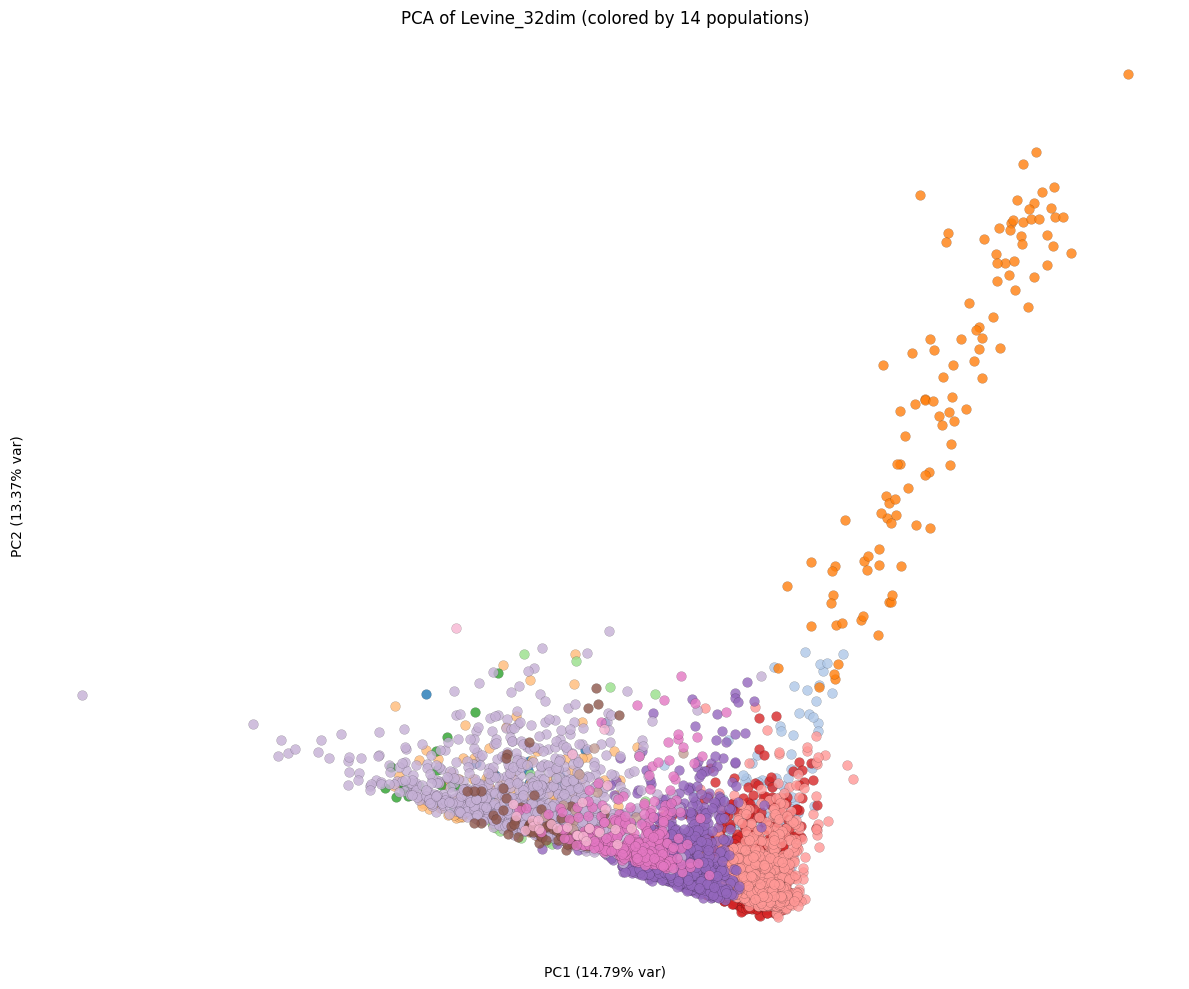

(<Figure size 1200x1000 with 1 Axes>,
 <Axes: title={'center': 'PCA of Levine_32dim (colored by 14 populations)'}, xlabel='PC1 (14.79% var)', ylabel='PC2 (13.37% var)'>)

In [10]:
plot_dim_red(
    X=X, y=y, method="pca", show_legend=False,
    title="PCA of Levine_32dim (colored by 14 populations)"
)

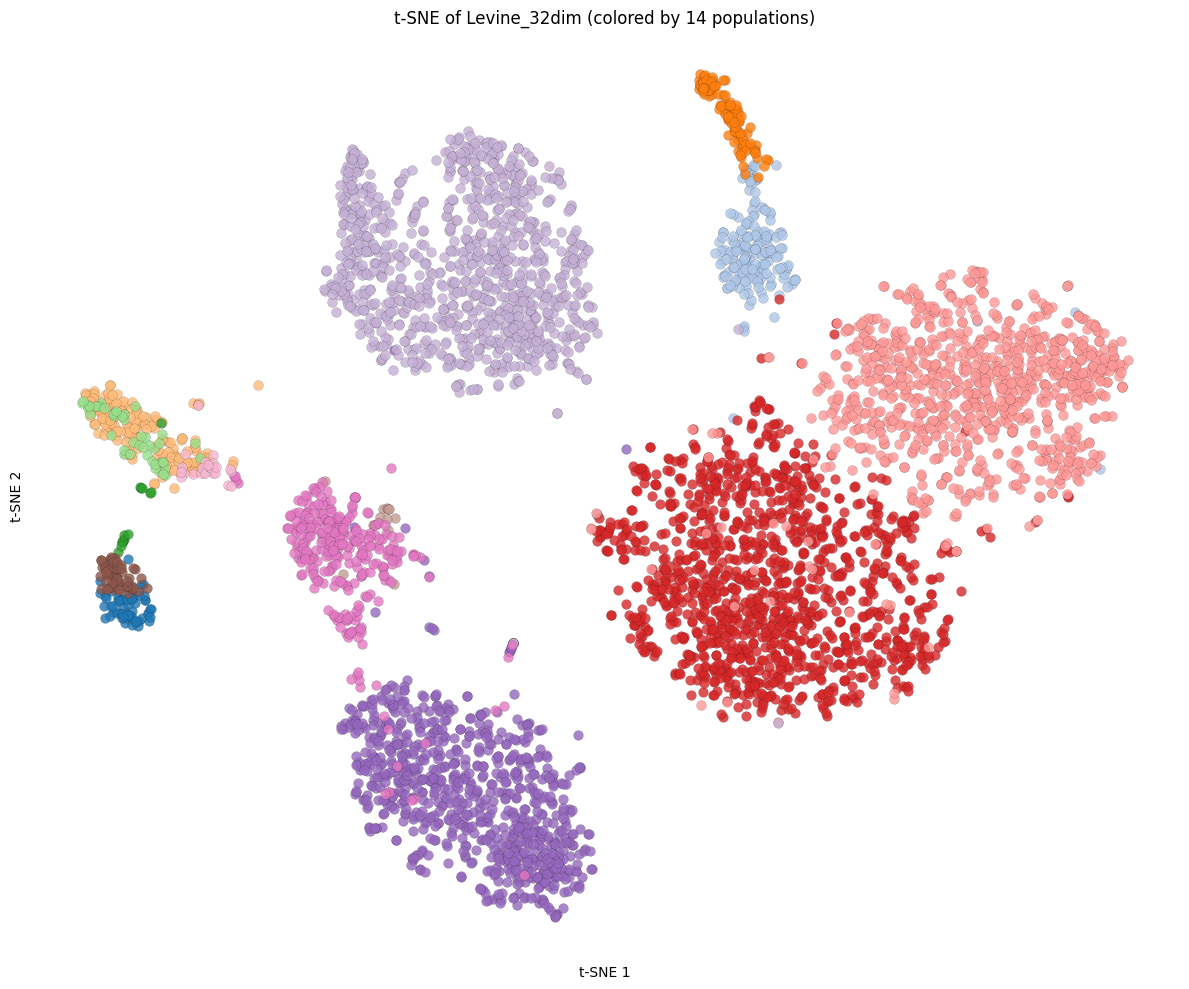

(<Figure size 1200x1000 with 1 Axes>,
 <Axes: title={'center': 't-SNE of Levine_32dim (colored by 14 populations)'}, xlabel='t-SNE 1', ylabel='t-SNE 2'>)

In [11]:
plot_dim_red(
    X=X, y=y, method="tsne", show_legend=False,
    title="t-SNE of Levine_32dim (colored by 14 populations)"
)

---

## 3. Baseline Metrics

We evaluate Silhouette, Gap statistic, Davies--Bouldin, and Calinski--Harabasz across k = 2..30 for KMeans and Agglomerative clustering (ward and single linkage):

In [12]:
ks = list(range(2, K + 1))

model_grids = [
    (KMeans, {"n_clusters": ks}),
    (AgglomerativeClustering, {"n_clusters": ks, "linkage": ["ward", "single"]}),
]

/Users/kaiwycik/GitHub/ClusteringValidation/code/.venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



baseline selections (max metric):
  - Silhouette: k=2, score=0.6797, ari=-0.0000   [Agglomerative (linkage=single)]
  - Gap Statistic: k=30, score=2.3180, ari=0.3602   [Agglomerative (linkage=ward)]
  - DB: k=2, score=0.8146, ari=-0.0000   [Agglomerative (linkage=single)]
  - CH: k=5, score=854.0824, ari=0.5752   [KMeans]


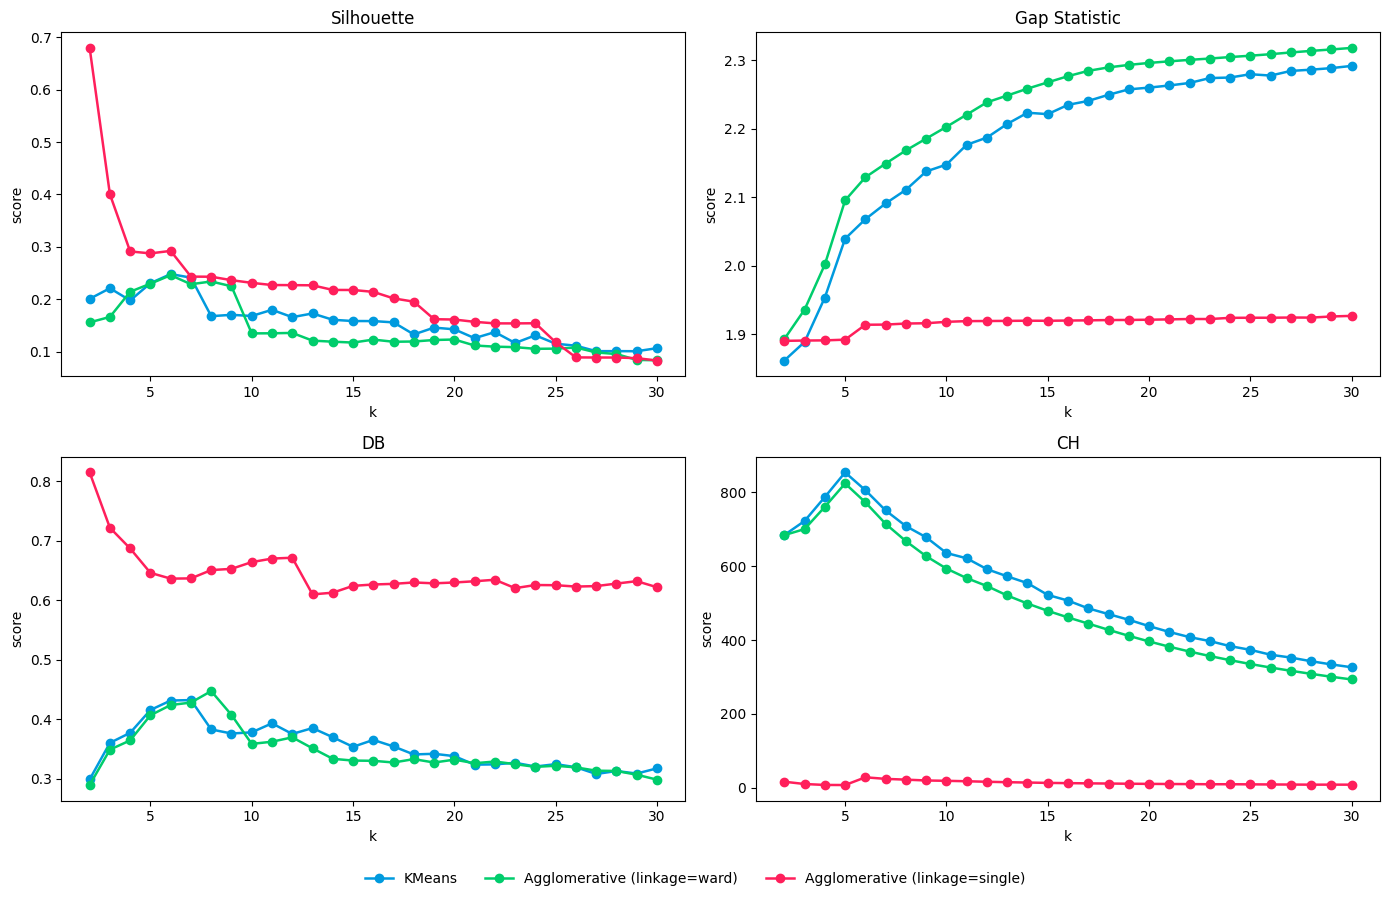

In [13]:
curves_df, best_df = baseline_metrics_over_k(
    X, y=y, model_grids=model_grids,
    metrics=["silhouette", "gap", "DB", "CH"],
    n_jobs=N_JOBS, random_state=RANDOM_SEED, ncols=2, figsize=(14, 9),
)

In [14]:
print("Best k selected by each metric:")
print(best_df[["metric", "best_model", "best_k", "best_ari"]].to_string(index=False))

Best k selected by each metric:
    metric                     best_model  best_k  best_ari
silhouette Agglomerative (linkage=single)       2 -0.000028
       gap   Agglomerative (linkage=ward)      30  0.360154
        DB Agglomerative (linkage=single)       2 -0.000028
        CH                         KMeans       5  0.575249


---

## 4. CARVE Analysis

In [15]:
carve_path = Path("./carve_state_saves/carve_levine32.carve")

if not carve_path.is_file():
    carve = CARVE(
        estimator_param_grids=model_grids, n_jobs=N_JOBS, random_state=RANDOM_SEED
    )
    carve.fit(X, reference_labels=y)

    # Save fitted state to avoid re-running
    carve_path.parent.mkdir(parents=True, exist_ok=True)
    carve.save(str(carve_path))
    print(f"Saved CARVE state to {carve_path}")
else:
    print(f"Loading CARVE state from {carve_path}")
    carve = CARVE.load(str(carve_path))
    carve.X_ = X

Loading CARVE state from carve_state_saves/carve_levine32.carve


<Axes: xlabel='Number of Clusters (k)', ylabel='ARI Stability'>

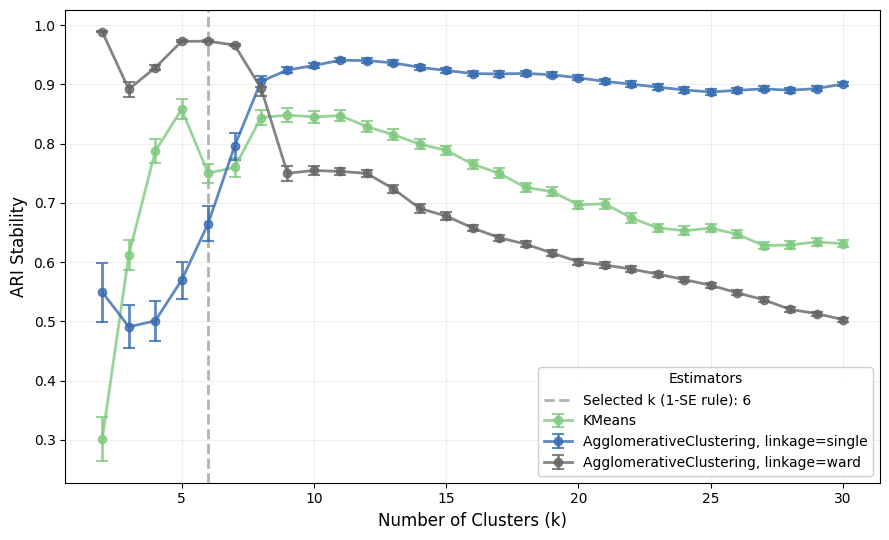

In [16]:
carve.plot_metric_over_n_clusters(measure=MEASURE, rule=RULE, not_two=NOT_TWO)

<Axes: xlabel='Number of Clusters (k)', ylabel='ARI Generalizability'>

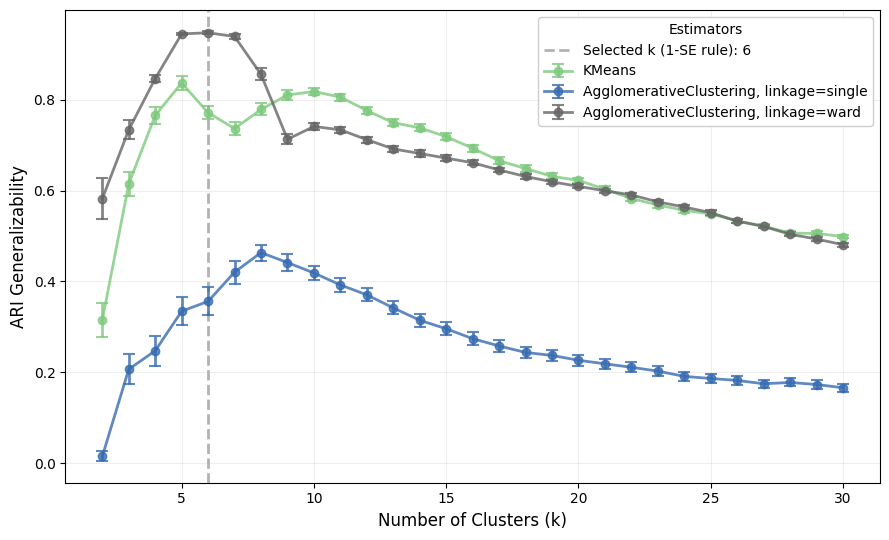

In [17]:
carve.plot_metric_over_n_clusters(measure="g", rule=RULE, not_two=NOT_TWO)

<Axes: xlabel='Samples (ordered by cluster)'>

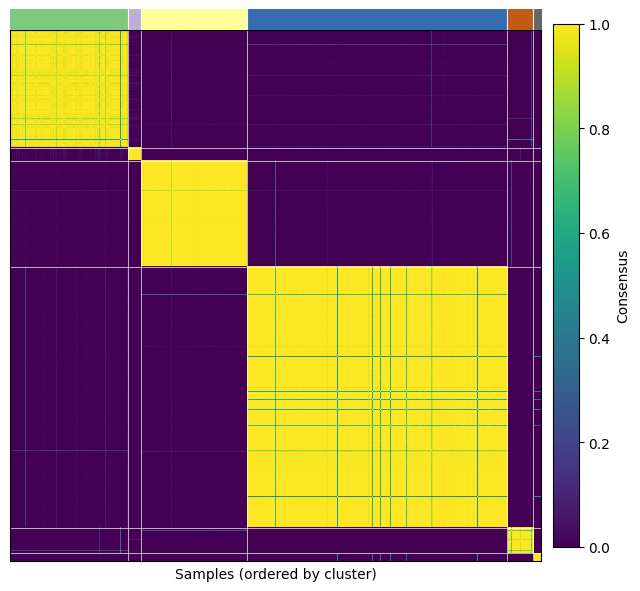

In [18]:
carve.plot_consensus_matrix(measure=MEASURE, rule=RULE, not_two=NOT_TWO)

<Axes: xlabel='Cluster', ylabel='Cluster Stability (Gini)'>

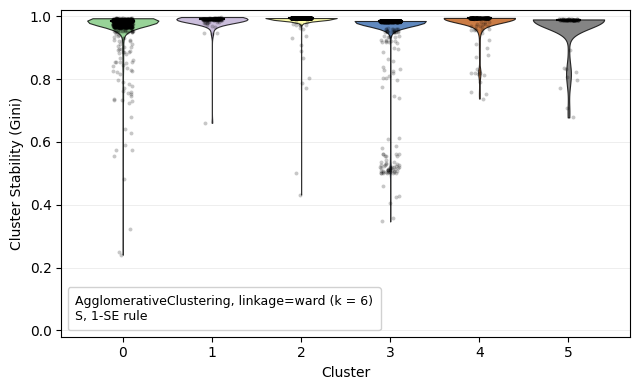

In [19]:
carve.plot_cluster_violin(measure=MEASURE, rule=RULE, not_two=NOT_TWO)

In [20]:
print(
      f"CARVE selects k={carve.get_k(measure=MEASURE, rule=RULE, not_two=NOT_TWO)} "
      f"(measure={MEASURE}, rule={RULE}, not_two={NOT_TWO})"
)

CARVE selects k=6 (measure=s, rule=1se, not_two=True)


---

## 5. Quantitative Comparison

### 5.1 Composite Paper Figure (with Alluvial)

In [21]:
ch_labels, ch_model, ch_k = build_baseline_best_labels(
    X, best_df, model_grids, metric="CH", random_state=RANDOM_SEED
)
print(f"Calinski-Harabasz selects: {ch_model}, k={ch_k}")

Calinski-Harabasz selects: KMeans, k=5


/Users/kaiwycik/GitHub/ClusteringValidation/code/notebooks/benchmarking_code/case_study_plotting.py:329: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


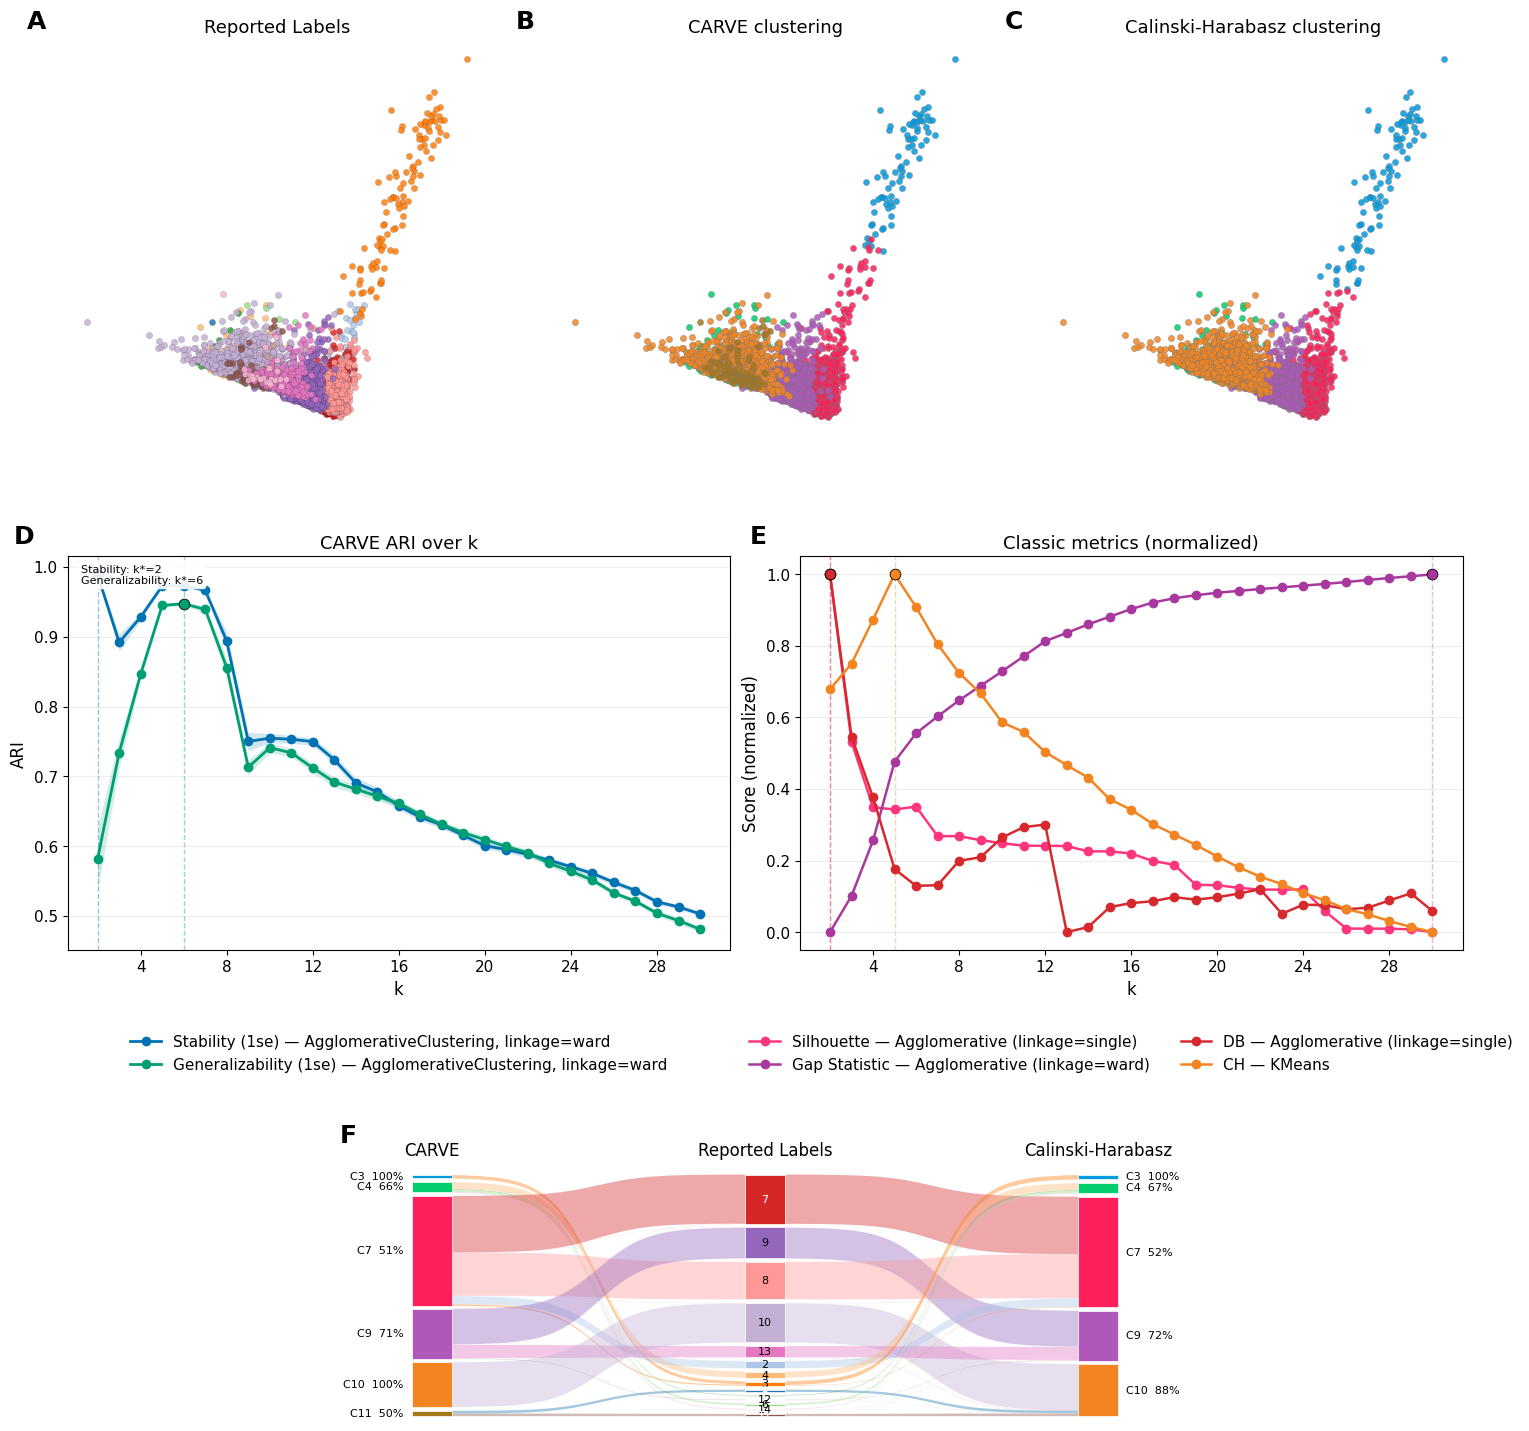

In [22]:
fig = plot_composite_figure(
    X, y, carve, curves_df, best_df, ch_labels,
    measure=MEASURE, rule=RULE,
    carve_measures=[("stability", "1se"), ("generalizability", "1se")],
    not_two=NOT_TWO,
    normalize_baseline=True,
    true_label_legend_title="Population",
    carve_title="CARVE clustering",
    baseline_title="Calinski-Harabasz clustering",
    carve_line_title="CARVE ARI over k",
    baseline_line_title="Classic metrics (normalized)",
    alluvial_left_title="CARVE",
    alluvial_right_title="Calinski-Harabasz",
    alluvial_true_title="Reported Labels",
    show_alluvial=True,
    figsize=(18, 16), scatter_s=20,
)

### 5.2 ARI with Ground Truth

In [23]:
ari_df = extract_ari_comparison(
    y_true=y, best_df=best_df, carve_obj=carve, X=X,
    carve_measures=[("stability", "1se"), ("generalizability", "1se")],
    not_two=NOT_TWO,
)
print(ari_df.to_string(index=False))

                      method                          model  k       ari   source
                  Silhouette Agglomerative (linkage=single)  2 -0.000028 baseline
               Gap Statistic   Agglomerative (linkage=ward) 30  0.360154 baseline
                          DB Agglomerative (linkage=single)  2 -0.000028 baseline
                          CH                         KMeans  5  0.575249 baseline
       CARVE Stability (1se)                CARVE consensus  6  0.584916    carve
CARVE Generalizability (1se)                CARVE consensus  6  0.584916    carve


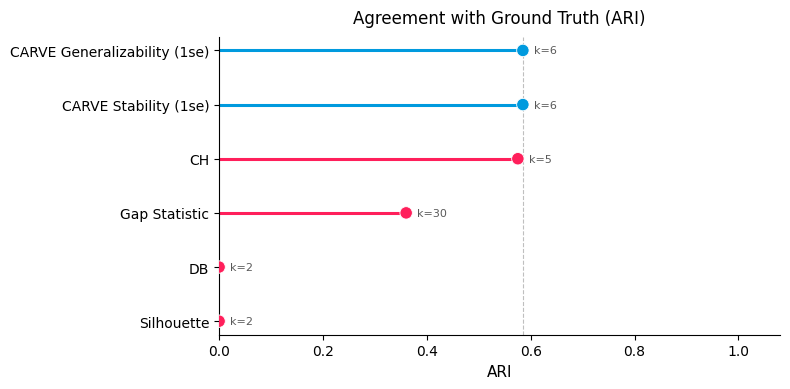

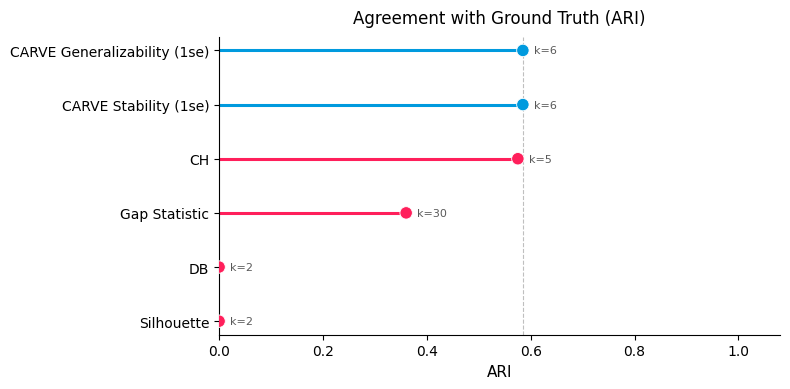

In [24]:
plot_ari_comparison_lollipop(ari_df)

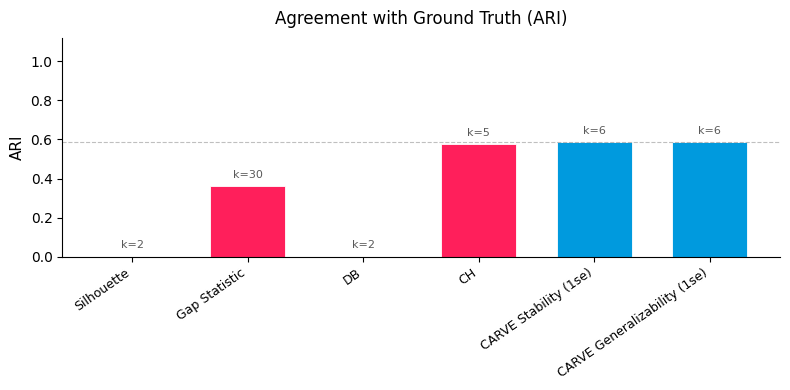

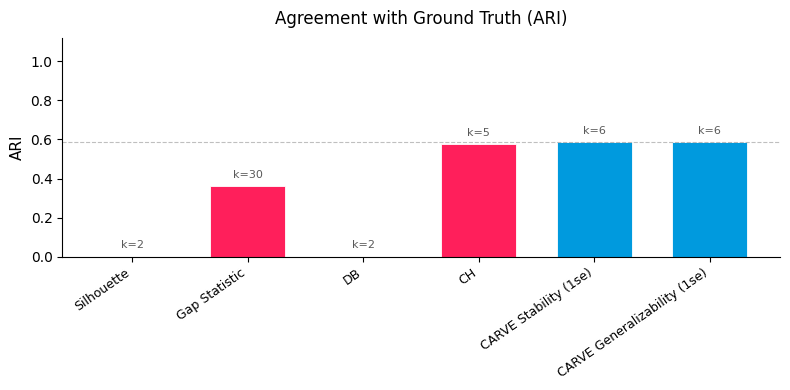

In [25]:
plot_ari_comparison_bar(ari_df)

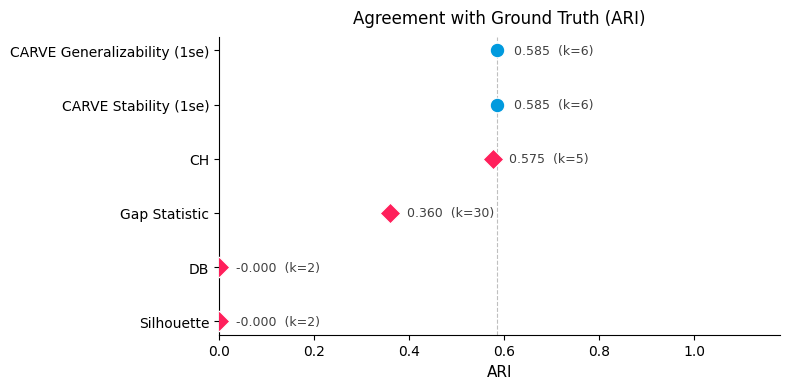

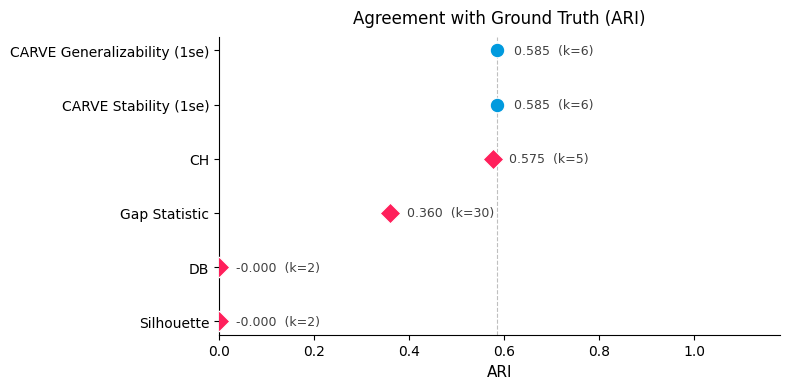

In [26]:
plot_ari_comparison_dotplot(ari_df)

### 5.3 Standalone Alluvial Diagram

In [28]:
carve_labels = carve.get_labels(measure=MEASURE, rule=RULE, not_two=NOT_TWO)

fig = alluvial_compare(
    y_true=y, left_labels=carve_labels, right_labels=ch_labels,
    left_title="CARVE", right_title="Calinski-Harabasz", true_title="Reported Labels",
    palette_name="tab10", link_alpha=0.35,
)
fig.show()

---

## 6. Summary

Levine_32dim is a canonical CyTOF benchmark with 14 manually gated bone marrow populations. The heavy-tailed protein expression distributions, overlapping populations, and varying population sizes challenge classical distance-based validation indices. We compare CARVE's stability-based selection (measure=s, rule=1se, not_two=True) against four classical metrics and quantify agreement with the 14 ground-truth populations using ARI.

---